Dimensionality d = 200
Train / test sizes: 80 / 5000
=== Baseline (no adversary) ===
Train loss: 1.0357e-11
Test  loss: 6.2597e+00

=== Algorithm 1: particle ascent (min–max) ===
Train loss on original inputs:    7.2168e+00
Train loss on adversarial inputs: 1.0038e+01
Test  loss (original inputs):     1.2365e+01
Final regularized objective J:    6.5556e-01
Final grad_theta norm:            3.6245e-02
Final grad_adv   norm:            1.4632e-01
Distance beta_alg1 to beta*:      4.9853e+00

=== Algorithm 2: ICNN-based transport (min–max) ===
Train loss (original inputs):          3.1395e-05
Test  loss  (original inputs):         6.7514e+00
Train loss with learned transport:     3.6422e-10
Final regularized objective J:         -4.6547e-03
Final grad_theta norm:                 3.9441e-05
Final grad_psi   norm:                 4.2436e-03
Distance theta (Alg2) to beta*:        3.6599e+00



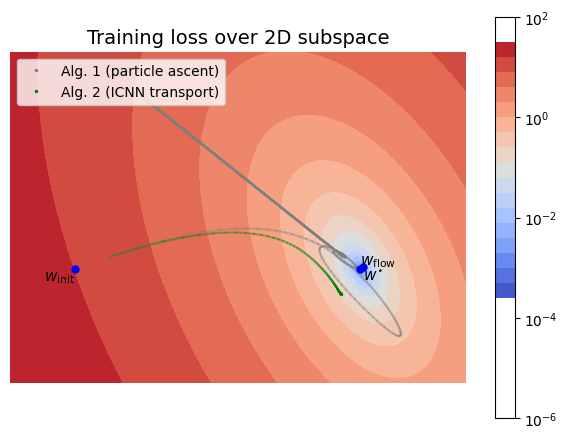

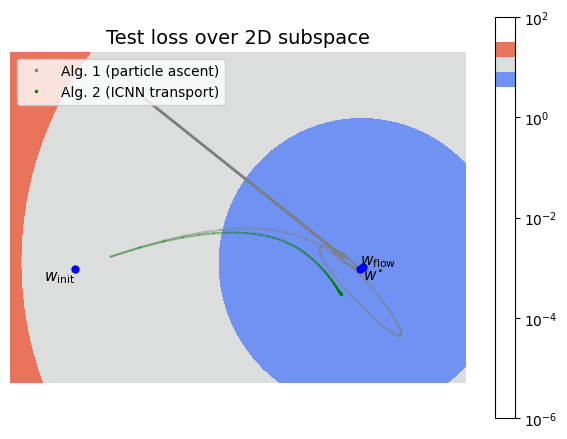

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils as nn_utils
import matplotlib.pyplot as plt
from matplotlib import ticker
from dataclasses import dataclass
from typing import Any, Optional, Tuple
from contextlib import nullcontext


# ============================================================
#  Basic setup
# ============================================================

def reset_seeds(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
reset_seeds(0)


# ============================================================
#  Synthetic diagonal-linear setting (Andriushchenko et al.)
# ============================================================

def make_teacher(d, sparsity, scale=1.0):
    """Sparse ground-truth vector β*."""
    beta = torch.zeros(d)
    idx = torch.randperm(d)[:sparsity]
    beta[idx] = scale * torch.randn(sparsity)
    return beta


def sample_data(n, beta):
    """X ~ N(0,I), y = X β*."""
    d = beta.numel()
    X = torch.randn(n, d)
    y = X @ beta
    return X, y


def mse_loss_Xbeta(X, beta, y):
    dev = beta.device
    Xd = X.to(dev)
    yd = y.to(dev)
    pred = Xd @ beta
    return 0.5 * ((pred - yd) ** 2).mean()


# ============================================================
#  BB + Armijo line search (for ascent)
# ============================================================

@dataclass
class BBArmijoState:
    alpha_min: float
    alpha_max: float
    alpha_prev: float
    ls_c: float
    ls_shrink: float
    ls_max_steps: int
    prev_params_vec: Optional[torch.Tensor] = None
    prev_grad_vec: Optional[torch.Tensor] = None

    @classmethod
    def create(
        cls,
        alpha0: float = 1e-1,
        alpha_min: float = 1e-6,
        alpha_max: float = 10.0,
        ls_c: float = 1e-4,
        ls_shrink: float = 0.5,
        ls_max_steps: int = 10,
    ) -> "BBArmijoState":
        alpha0 = float(max(alpha_min, min(alpha_max, alpha0)))
        return cls(
            alpha_min=float(max(alpha_min, 1e-12)),
            alpha_max=float(max(alpha_max, alpha_min)),
            alpha_prev=alpha0,
            ls_c=float(ls_c),
            ls_shrink=float(ls_shrink),
            ls_max_steps=int(max(ls_max_steps, 1)),
        )

    def propose(self, params_vec: torch.Tensor, grad_vec: torch.Tensor) -> float:
        """Propose a BB step size (no Armijo yet)."""
        if (
            self.prev_params_vec is None
            or self.prev_grad_vec is None
            or self.prev_params_vec.shape != params_vec.shape
            or self.prev_grad_vec.shape != grad_vec.shape
        ):
            alpha = self.alpha_prev
        else:
            s = params_vec - self.prev_params_vec
            y = grad_vec - self.prev_grad_vec
            denom = torch.dot(s, y)
            num = torch.dot(s, s)
            cond = torch.isfinite(denom) & (torch.abs(denom) > 1e-12)
            alpha_bb = torch.where(cond, num / denom, torch.tensor(self.alpha_prev, device=denom.device))
            alpha = float(alpha_bb.clamp(self.alpha_min, self.alpha_max).item())

        if not math.isfinite(alpha):
            alpha = self.alpha_prev
        alpha = max(self.alpha_min, min(self.alpha_max, float(alpha)))
        return alpha

    def update_history(self, params_vec: torch.Tensor, grad_vec: torch.Tensor, alpha: float) -> "BBArmijoState":
        alpha_clamped = max(self.alpha_min, min(self.alpha_max, float(alpha)))
        return BBArmijoState(
            alpha_min=self.alpha_min,
            alpha_max=self.alpha_max,
            alpha_prev=alpha_clamped,
            ls_c=self.ls_c,
            ls_shrink=self.ls_shrink,
            ls_max_steps=self.ls_max_steps,
            prev_params_vec=params_vec.detach().clone(),
            prev_grad_vec=grad_vec.detach().clone(),
        )


def bb_armijo_ascent_x(
    x0: torch.Tensor,
    f,
    num_steps: int,
    bb_state: Optional[BBArmijoState] = None,
) -> Tuple[torch.Tensor, BBArmijoState, Optional[torch.Tensor]]:
    """
    Gradient ascent on x with BB step size + Armijo backtracking.

    f: x -> scalar objective (maximized).
    """
    if x0.numel() == 0 or num_steps == 0:
        state = bb_state if bb_state is not None else BBArmijoState.create()
        return x0, state, None

    state = bb_state if bb_state is not None else BBArmijoState.create()

    x = x0
    last_grad = None
    for _ in range(num_steps):
        x_req = x.detach().requires_grad_(True)
        fx = f(x_req)
        g = torch.autograd.grad(fx, x_req, create_graph=False, retain_graph=False)[0]
        g_vec = g.reshape(-1).detach()
        x_vec = x_req.detach().reshape(-1)
        alpha = state.propose(x_vec, g_vec)

        fx_val = float(fx.detach())
        g_dot_g = float(torch.dot(g_vec, g_vec).item())
        if g_dot_g == 0.0:
            break

        alpha_k = alpha
        for _ in range(state.ls_max_steps):
            x_trial = x_req + alpha_k * g
            f_trial = float(f(x_trial).detach())
            if f_trial >= fx_val + state.ls_c * alpha_k * g_dot_g:
                break
            alpha_k *= state.ls_shrink

        x_new = (x_req + alpha_k * g).detach()
        x_new_req = x_new.requires_grad_(True)
        g_new = torch.autograd.grad(f(x_new_req), x_new_req, create_graph=False, retain_graph=False)[0]
        state = state.update_history(x_new_req.detach().reshape(-1), g_new.detach().reshape(-1), alpha_k)
        x = x_new.detach()
        last_grad = g_new.detach()

    return x, state, last_grad


def bb_armijo_step_params(
    params: Any,
    f_params,
    bb_state: BBArmijoState,
) -> Tuple[Any, BBArmijoState, float, float]:
    """
    Single BB+Armijo gradient-ascent step on a parameter collection.

    f_params: callable taking a boolean `create_graph` flag and returning scalar objective (maximized).
    """
    params = list(params)
    params_vec = nn_utils.parameters_to_vector(params).detach()

    f_val = f_params(True)
    grads = torch.autograd.grad(
        f_val,
        params,
        create_graph=False,
        retain_graph=False,
        allow_unused=True,
    )
    grad_tensors = [g.detach() if g is not None else torch.zeros_like(p) for p, g in zip(params, grads)]
    grad_vec = nn_utils.parameters_to_vector(grad_tensors)
    grad_norm = grad_vec.norm().item()

    alpha = bb_state.propose(params_vec, grad_vec)
    f_val_float = float(f_val.detach())
    g_dot_g = float(torch.dot(grad_vec, grad_vec).item())
    if g_dot_g == 0.0:
        return params, bb_state, f_val_float, grad_norm

    alpha_k = alpha
    for _ in range(bb_state.ls_max_steps):
        trial_vec = params_vec + alpha_k * grad_vec
        with torch.no_grad():
            nn_utils.vector_to_parameters(trial_vec, params)
            f_trial = float(f_params(False).detach())
        if f_trial >= f_val_float + bb_state.ls_c * alpha_k * g_dot_g:
            break
        alpha_k *= bb_state.ls_shrink

    final_vec = params_vec + alpha_k * grad_vec
    with torch.no_grad():
        nn_utils.vector_to_parameters(final_vec, params)

    f_new = f_params(True)
    grads_new = torch.autograd.grad(
        f_new,
        params,
        create_graph=False,
        retain_graph=False,
        allow_unused=True,
    )
    grad_tensors_new = [g.detach() if g is not None else torch.zeros_like(p) for p, g in zip(params, grads_new)]
    grad_vec_new = nn_utils.parameters_to_vector(grad_tensors_new)
    new_state = bb_state.update_history(final_vec, grad_vec_new, alpha_k)
    return params, new_state, f_val_float, grad_vec_new.norm().item()


# ============================================================
#  ICNN components (Input-Convex Potential φ_ψ)
# ============================================================


def icnn_principled_moments(fan_in: int):
    """Principled log-normal moments for positive weights."""
    if fan_in <= 0:
        raise ValueError(f"ICNN fan-in must be positive; got {fan_in}.")
    denom_offset = 6.0 * (math.pi - 1.0)
    denom_slope = 3.0 * math.sqrt(3.0) + 2.0 * math.pi - 6.0
    denom = denom_offset + (fan_in - 1.0) * denom_slope
    mu_w = math.sqrt((6.0 * math.pi) / (fan_in * denom))
    sigma_w2 = 1.0 / float(fan_in)
    mu_b = math.sqrt((3.0 * fan_in) / denom)
    mu_w_sq = mu_w * mu_w
    log_var_plus_mean_sq = math.log(sigma_w2 + mu_w_sq)
    log_mean_sq = math.log(mu_w_sq)
    tilde_mu = log_mean_sq - 0.5 * log_var_plus_mean_sq
    tilde_sigma2 = max(log_var_plus_mean_sq - log_mean_sq, 1e-12)
    tilde_sigma = math.sqrt(tilde_sigma2)
    return mu_w, sigma_w2, mu_b, tilde_mu, tilde_sigma


class NonNegativeLinear(nn.Module):
    """Linear map with strictly non-negative weights via exp/softplus."""
    def __init__(self, in_features, out_features, bias=True, init_mode="principled"):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.use_bias = bias
        self.init_mode = init_mode.lower()
        if self.init_mode not in {"principled", "xavier"}:
            raise ValueError(f"Unsupported init_mode '{init_mode}' for NonNegativeLinear.")
        self.parametrization = "exp" if self.init_mode == "principled" else "softplus"

        self.weight_param = nn.Parameter(torch.empty(in_features, out_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter("bias", None)

        self.reset_parameters()

    def reset_parameters(self):
        if self.init_mode == "principled":
            mu_w, sigma_w2, mu_b, tilde_mu, tilde_sigma = icnn_principled_moments(self.in_features)
            with torch.no_grad():
                if tilde_sigma == 0.0:
                    self.weight_param.fill_(tilde_mu)
                else:
                    self.weight_param.normal_(mean=tilde_mu, std=tilde_sigma)
                if self.bias is not None:
                    self.bias.fill_(mu_b)
        else:
            nn.init.xavier_uniform_(self.weight_param)
            if self.bias is not None:
                nn.init.zeros_(self.bias)

    def forward(self, x):
        if self.parametrization == "exp":
            weight = torch.exp(self.weight_param)
        else:
            weight = F.softplus(self.weight_param)
        y = x.matmul(weight)
        if self.bias is not None:
            y = y + self.bias
        return y


class InputConvexPotential(nn.Module):
    """
    Dense ICNN potential φ(z):
      φ(z) = 0.5 μ ||z||² + aᵀ z + g(z; ψ)
    with non-negative couplings for convexity.
    """
    def __init__(
        self,
        input_dim=2,
        hidden_sizes=(64, 64, 64),
        activation="softplus",
        strong_convexity=1.0,
        nonneg_init="principled",
        softplus_beta=20.0,
    ):
        super().__init__()
        if len(hidden_sizes) == 0:
            raise ValueError("ICNN requires at least one hidden layer.")
        self.input_dim = input_dim
        self.hidden_sizes = hidden_sizes
        self.activation = activation
        self.strong_convexity = strong_convexity
        self.softplus_beta = softplus_beta

        self.z_linears = nn.ModuleList()
        self.h_linears = nn.ModuleList()
        for i, width in enumerate(hidden_sizes):
            self.z_linears.append(nn.Linear(input_dim, width, bias=True))
            if i == 0:
                self.h_linears.append(None)
            else:
                self.h_linears.append(
                    NonNegativeLinear(
                        hidden_sizes[i - 1],
                        width,
                        bias=False,
                        init_mode=nonneg_init,
                    )
                )

        self.hidden_output = NonNegativeLinear(
            hidden_sizes[-1],
            1,
            bias=True,
            init_mode=nonneg_init,
        )
        self.input_skip = nn.Linear(input_dim, 1, bias=True)

    def _activation(self):
        act_name = self.activation.lower()
        if act_name == "relu":
            return F.relu
        if act_name == "softplus":
            beta = float(self.softplus_beta)
            return lambda u: F.softplus(beta * u) / beta
        raise ValueError(f"Unsupported ICNN activation '{self.activation}'.")

    def forward(self, x):
        """
        x: (n, d); returns scalar potential φ(x) per sample.
        """
        z = x.view(x.size(0), -1)
        act = self._activation()

        h = act(self.z_linears[0](z))
        for k in range(1, len(self.z_linears)):
            z_term = self.z_linears[k](z)
            h_term = self.h_linears[k](h) if self.h_linears[k] is not None else 0.0
            h = act(z_term + h_term)

        quadratic = 0.5 * self.strong_convexity * (z ** 2).sum(dim=1, keepdim=True)
        out = quadratic + self.input_skip(z) + self.hidden_output(h)
        return out.squeeze(-1)


ICNN = InputConvexPotential


def icnn_transport(icnn, x, create_graph=False):
    """
    Compute T_ψ(x) = ∇_x φ_ψ(x) via autograd.
    Returns T_ψ(x) with same shape as x.
    """
    x_in = x.clone().detach().requires_grad_(True)
    # Ensure grad tracking even if called under torch.no_grad()
    with torch.set_grad_enabled(True):
        phi = icnn(x_in)
        grads = torch.autograd.grad(
            outputs=phi.sum(),
            inputs=x_in,
            create_graph=create_graph,
        )[0]
    return grads.view_as(x)


# ============================================================
#  Linear model for θ (core network)
# ============================================================

class LinearRegressor(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(d))

    def forward(self, X):
        return X @ self.theta

    def beta(self):
        return self.theta.detach().clone()


def mse_loss_from_model(model, X, y):
    pred = model(X)
    return 0.5 * ((pred - y) ** 2).mean()


# ============================================================
#  Algorithm 1: Particle ascent (min–max in x)
# ============================================================

def train_algorithm1(
    model,
    X,
    y,
    lam=0.5,
    inner_steps=5,
    lr_theta=0.05,
    lr_inner=0.1,
    num_iters=2000,
    use_bb_adv=False,
):
    """
    Algorithm 1 (particle ascent) in the diagonal-linear setting.

    Inner loop:   x ← argmax_x [ ℓ(θ, x) − λ ||x − x₀||² ]
    Outer loop:   θ ← argmin_θ ℓ(θ, x_adv)
    """
    model.to(device)
    Xd = X.to(device)
    yd = y.to(device)

    adv = Xd.clone()  # stateful adversarial particles

    opt_theta = torch.optim.SGD(model.parameters(), lr=lr_theta)
    bb_state_adv = BBArmijoState.create(alpha0=lr_inner) if use_bb_adv else None

    logs = {
        "theta_hist": [],
        "J_hist": [],
        "train_loss_orig": [],
        "train_loss_adv": [],
        "grad_theta_norm": [],
        "grad_adv_norm": [],
    }

    for t in range(num_iters):
        # ---- inner ascent on adversarial inputs (max over x) ----
        last_grad_x = None
        if use_bb_adv:
            theta_frozen = model.theta.detach()

            def f_adv(x_adv):
                pred_adv = x_adv @ theta_frozen
                loss_adv = 0.5 * ((pred_adv - yd) ** 2).mean()
                reg = ((x_adv - Xd) ** 2).sum(dim=1).mean()
                return loss_adv - lam * reg

            adv, bb_state_adv, last_grad_x = bb_armijo_ascent_x(
                adv,
                f_adv,
                num_steps=inner_steps,
                bb_state=bb_state_adv,
            )
        else:
            adv_t = adv.clone().detach()
            for s in range(1, inner_steps + 1):
                adv_t.requires_grad_(True)
                pred_adv = adv_t @ model.theta
                loss_adv = 0.5 * ((pred_adv - yd) ** 2).mean()
                reg = ((adv_t - Xd) ** 2).sum(dim=1).mean()
                J = loss_adv - lam * reg

                grad_x = torch.autograd.grad(J, adv_t)[0]
                step = lr_inner / math.sqrt(s)
                with torch.no_grad():
                    adv_t = adv_t + step * grad_x
                last_grad_x = grad_x.detach()

            adv = adv_t.detach()

        # ---- outer descent on θ (min over θ) ----
        opt_theta.zero_grad()
        pred_outer = adv @ model.theta
        loss_outer = 0.5 * ((pred_outer - yd) ** 2).mean()
        loss_outer.backward()
        grad_theta_norm = model.theta.grad.detach().norm().item()
        opt_theta.step()

        # ---- logging ----
        with torch.no_grad():
            train_orig = mse_loss_Xbeta(Xd, model.theta, yd).item()
            train_adv = mse_loss_Xbeta(adv, model.theta, yd).item()
            reg_final = ((adv - Xd) ** 2).sum(dim=1).mean().item()
            J_val = train_adv - lam * reg_final
            grad_adv_norm = (
                last_grad_x.view(last_grad_x.size(0), -1).norm(dim=1).mean().item()
                if last_grad_x is not None
                else 0.0
            )

            logs["theta_hist"].append(model.theta.detach().cpu().clone())
            logs["J_hist"].append(J_val)
            logs["train_loss_orig"].append(train_orig)
            logs["train_loss_adv"].append(train_adv)
            logs["grad_theta_norm"].append(grad_theta_norm)
            logs["grad_adv_norm"].append(grad_adv_norm)

    return model, adv, logs


# ============================================================
#  Algorithm 2: ICNN transport (min–max in ψ)
# ============================================================

def parameter_grad_norm(parameters):
    sq_norms = []
    for p in parameters:
        if p.grad is not None:
            sq_norms.append(p.grad.detach().norm() ** 2)
    if not sq_norms:
        return 0.0
    return torch.sqrt(torch.stack(sq_norms).sum()).item()


def train_algorithm2(
    model,
    icnn,
    X,
    y,
    lam=0.5,
    inner_steps=5,
    lr_theta=0.05,
    lr_psi=0.05,
    num_iters=2000,
    use_bb_psi=False,
):
    """
    Algorithm 2 (ICNN transport) in the diagonal-linear setting.

        min_θ max_ψ  E[ ℓ(θ, T_ψ(x)) − λ ||T_ψ(x) − x||² ]
    where T_ψ(x) = ∇_x φ_ψ(x).
    """
    model.to(device)
    icnn.to(device)

    Xd = X.to(device)
    yd = y.to(device)

    opt_theta = torch.optim.SGD(model.parameters(), lr=lr_theta)
    opt_psi = torch.optim.SGD(icnn.parameters(), lr=lr_psi)
    bb_state_psi = BBArmijoState.create(alpha0=lr_psi) if use_bb_psi else None

    logs = {
        "theta_hist": [],
        "J_hist": [],
        "train_loss_orig": [],
        "train_loss_transport": [],
        "grad_theta_norm": [],
        "grad_psi_norm": [],
    }

    for t in range(num_iters):
        # ---- inner maximization over ψ (ICNN parameters); freeze θ ----
        last_grad_psi_norm = 0.0
        theta_frozen = model.theta.detach()
        if use_bb_psi:
            for _ in range(inner_steps):
                def psi_objective(create_graph: bool):
                    T_x_local = icnn_transport(icnn, Xd, create_graph=create_graph)
                    pred_adv = T_x_local @ theta_frozen
                    loss_adv = 0.5 * ((pred_adv - yd) ** 2).mean()
                    reg = ((T_x_local - Xd) ** 2).sum(dim=1).mean()
                    return loss_adv - lam * reg

                icnn_params = icnn.parameters()
                icnn_params, bb_state_psi, _fval, last_grad_psi_norm = bb_armijo_step_params(
                    icnn_params,
                    psi_objective,
                    bb_state_psi,
                )
        else:
            for _ in range(inner_steps):
                T_x = icnn_transport(icnn, Xd, create_graph=True)
                pred_adv = T_x @ theta_frozen
                loss_adv = 0.5 * ((pred_adv - yd) ** 2).mean()
                reg = ((T_x - Xd) ** 2).sum(dim=1).mean()
                J = loss_adv - lam * reg  # maximize over ψ

                opt_psi.zero_grad(set_to_none=True)
                psi_loss = -J  # gradient ascent on J
                psi_loss.backward()
                last_grad_psi_norm = parameter_grad_norm(icnn.parameters())
                opt_psi.step()

        # ---- outer minimization over θ (core linear model); freeze ψ ----
        T_x_outer = icnn_transport(icnn, Xd, create_graph=False).detach()
        opt_theta.zero_grad(set_to_none=True)
        pred_outer = T_x_outer @ model.theta
        loss_outer = 0.5 * ((pred_outer - yd) ** 2).mean()
        loss_outer.backward()
        grad_theta_norm = model.theta.grad.detach().norm().item()
        opt_theta.step()

        # ---- logging ----
        with torch.no_grad():
            train_orig = mse_loss_Xbeta(Xd, model.theta, yd).item()
            train_transport = mse_loss_Xbeta(T_x_outer, model.theta, yd).item()
            reg_outer = ((T_x_outer - Xd) ** 2).sum(dim=1).mean().item()
            J_val = train_transport - lam * reg_outer

            logs["theta_hist"].append(model.theta.detach().cpu().clone())
            logs["J_hist"].append(J_val)
            logs["train_loss_orig"].append(train_orig)
            logs["train_loss_transport"].append(train_transport)
            logs["grad_theta_norm"].append(grad_theta_norm)
            logs["grad_psi_norm"].append(last_grad_psi_norm)

    return model, icnn, logs


# ============================================================
#  2D loss landscape + trajectories (θ-space only)
# ============================================================

def evaluate_losses(beta, X_train, y_train, X_test, y_test):
    train_loss = mse_loss_Xbeta(X_train, beta, y_train).item()
    test_loss = mse_loss_Xbeta(X_test, beta, y_test).item()
    return train_loss, test_loss


def build_plane_basis(theta_init, theta_flow, theta_ref):
    """
    Build an orthonormal 2D basis (e1, e2) in θ-space.

    e1 is along (θ_flow − θ_init).
    e2 is the component of (θ_ref − θ_init) orthogonal to e1.
    """
    d1 = theta_flow - theta_init
    n1 = d1.norm()
    if n1 < 1e-8:
        raise RuntimeError("θ_flow and θ_init are (almost) identical; cannot build basis.")
    e1 = d1 / n1

    v2 = theta_ref - theta_init
    proj = torch.dot(v2, e1) * e1
    v2_ortho = v2 - proj
    n2 = v2_ortho.norm()
    if n2 < 1e-8:
        # fallback: random direction orthogonal to e1
        rnd = torch.randn_like(e1)
        rnd = rnd - torch.dot(rnd, e1) * e1
        v2_ortho = rnd
        n2 = v2_ortho.norm()
    e2 = v2_ortho / n2
    return e1, e2


def project_to_plane(theta, theta0, e1, e2):
    diff = theta - theta0
    alpha = torch.dot(diff, e1).item()
    beta = torch.dot(diff, e2).item()
    return alpha, beta


def plot_loss_surface_and_trajectories(
    X_train,
    y_train,
    X_test,
    y_test,
    theta_init,
    theta_flow,
    beta_star,
    logs_alg1,
    logs_alg2,
    n_pts=80,
    log_base=2.0,
):
    """
    Replicates Fig. 3-style 2D landscape, but purely in θ-space:
      - 2D plane through θ_init, θ_flow, and Alg.1 trajectory.
      - show trajectories of Alg.1 and Alg.2 projected on this plane.
    """
    theta_init = theta_init.cpu()
    theta_flow = theta_flow.cpu()
    beta_star = beta_star.cpu()
    X_train = X_train.cpu()
    y_train = y_train.cpu()
    X_test = X_test.cpu()
    y_test = y_test.cpu()

    # Build basis from θ_init, θ_flow and final θ_alg1
    theta_alg1_final = logs_alg1["theta_hist"][-1]
    e1, e2 = build_plane_basis(theta_init, theta_flow, theta_alg1_final)

    # Collect all interesting θ's for axis ranges
    traj1 = torch.stack(logs_alg1["theta_hist"])
    traj2 = torch.stack(logs_alg2["theta_hist"])
    thetas_for_range = torch.cat(
        [traj1, traj2, theta_init[None, :], theta_flow[None, :], beta_star[None, :]],
        dim=0,
    )

    alphas = []
    betas = []
    for theta in thetas_for_range:
        a, b = project_to_plane(theta, theta_init, e1, e2)
        alphas.append(a)
        betas.append(b)

    a_min, a_max = min(alphas), max(alphas)
    b_min, b_max = min(betas), max(betas)

    # Add some margin around the trajectories / reference points
    a_margin = 0.2 * (a_max - a_min + 1e-6)
    b_margin = 0.2 * (b_max - b_min + 1e-6)
    a_min -= a_margin
    a_max += a_margin
    b_min -= b_margin
    b_max += b_margin

    grid_alphas = np.linspace(a_min, a_max, n_pts)
    grid_betas = np.linspace(b_min, b_max, n_pts)
    train_grid = np.zeros((n_pts, n_pts))
    test_grid = np.zeros((n_pts, n_pts))

    # Evaluate loss on the 2D plane
    for i, alpha in enumerate(grid_alphas):
        for j, beta in enumerate(grid_betas):
            theta = theta_init + alpha * e1 + beta * e2
            tr, te = evaluate_losses(theta, X_train, y_train, X_test, y_test)
            # swap indices to match contourf convention in original code
            train_grid[j, i] = max(tr, 1e-6)
            test_grid[j, i] = max(te, 1e-6)

    max_allowed = 100.0
    train_grid[train_grid > max_allowed] = max_allowed
    test_grid[test_grid > max_allowed] = max_allowed

    # Helper to plot trajectories
    def plot_trajectory(ax, thetas, color, label):
        al_prev, be_prev = project_to_plane(thetas[0], theta_init, e1, e2)
        for k in range(1, len(thetas)):
            al, be = project_to_plane(thetas[k], theta_init, e1, e2)
            ax.plot([al_prev, al], [be_prev, be], color=color, alpha=0.4)
            al_prev, be_prev = al, be
        ax.plot(al_prev, be_prev, ".", color=color, markersize=3.0, label=label)

    # ========== Training loss ==========
    fig, ax = plt.subplots(figsize=(6, 4.5))
    cs = ax.contourf(
        grid_alphas,
        grid_betas,
        train_grid,
        cmap="coolwarm",
        locator=ticker.LogLocator(base=log_base, numticks=30),
    )
    cbar = plt.colorbar(cs)
    cbar.set_ticks([1e-6, 1e-4, 1e-2, 1e0, 1e2])

    plot_trajectory(ax, traj1, color="gray", label="Alg. 1 (particle ascent)")
    plot_trajectory(ax, traj2, color="green", label="Alg. 2 (ICNN transport)")

    # Mark θ_init, θ_flow, β*
    a0, b0 = project_to_plane(theta_init, theta_init, e1, e2)
    af, bf = project_to_plane(theta_flow, theta_init, e1, e2)
    a_star, b_star = project_to_plane(beta_star, theta_init, e1, e2)

    ax.plot(a0, b0, "o", color="blue", markersize=5.0)
    ax.annotate(r"$w_{\mathrm{init}}$", (a0, b0),
                fontsize=11, ha="right", va="top")
    ax.plot(af, bf, "o", color="blue", markersize=5.0)
    ax.annotate(r"$w_{\mathrm{flow}}$", (af, bf),
                fontsize=11, ha="left", va="bottom")
    ax.plot(a_star, b_star, "o", color="blue", markersize=5.0)
    ax.annotate(r"$w^{\star}$", (a_star, b_star),
                fontsize=11, ha="left", va="top")

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Training loss over 2D subspace", fontsize=14)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # ========== Test loss ==========
    fig, ax = plt.subplots(figsize=(6, 4.5))
    cs = ax.contourf(
        grid_alphas,
        grid_betas,
        test_grid,
        cmap="coolwarm",
        locator=ticker.LogLocator(base=log_base, numticks=30),
    )
    cbar = plt.colorbar(cs)
    cbar.set_ticks([1e-6, 1e-4, 1e-2, 1e0, 1e2])

    plot_trajectory(ax, traj1, color="gray", label="Alg. 1 (particle ascent)")
    plot_trajectory(ax, traj2, color="green", label="Alg. 2 (ICNN transport)")

    # Same markers
    ax.plot(a0, b0, "o", color="blue", markersize=5.0)
    ax.annotate(r"$w_{\mathrm{init}}$", (a0, b0),
                fontsize=11, ha="right", va="top")
    ax.plot(af, bf, "o", color="blue", markersize=5.0)
    ax.annotate(r"$w_{\mathrm{flow}}$", (af, bf),
                fontsize=11, ha="left", va="bottom")
    ax.plot(a_star, b_star, "o", color="blue", markersize=5.0)
    ax.annotate(r"$w^{\star}$", (a_star, b_star),
                fontsize=11, ha="left", va="top")

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Test loss over 2D subspace", fontsize=14)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


# ============================================================
#  Run full experiment
# ============================================================

def main():
    # Problem setup
    d = 200
    n_train = 80
    n_test = 5000
    sparsity = 20

    reset_seeds(0)
    beta_star = make_teacher(d, sparsity, scale=1.0)
    X_train, y_train = sample_data(n_train, beta_star)
    X_test, y_test = sample_data(n_test, beta_star)

    print(f"Dimensionality d = {d}")
    print(f"Train / test sizes: {n_train} / {n_test}")

    # ----- baseline (no adversary): minimal-norm interpolator -----
    beta_flow = torch.linalg.pinv(X_train) @ y_train
    base_train, base_test = evaluate_losses(beta_flow, X_train, y_train, X_test, y_test)

    print("=== Baseline (no adversary) ===")
    print(f"Train loss: {base_train:.4e}")
    print(f"Test  loss: {base_test:.4e}")
    print()

    lam = 5.0
    inner_steps = 10
    num_iters = 2000

    # Common initialization for both algorithms
    theta_init = 0.1 * torch.ones(d)

    # ----- Algorithm 1 -----
    reset_seeds(1)
    alg1_model = LinearRegressor(d)
    with torch.no_grad():
        alg1_model.theta.copy_(theta_init)

    alg1_model, adv_points, logs_alg1 = train_algorithm1(
        alg1_model,
        X_train,
        y_train,
        lam=lam,
        inner_steps=inner_steps,
        lr_theta=0.05,
        lr_inner=0.1,
        num_iters=num_iters,
        use_bb_adv=True,
    )

    beta_alg1 = alg1_model.beta()
    train_orig_alg1, test_orig_alg1 = evaluate_losses(beta_alg1, X_train, y_train, X_test, y_test)
    train_adv_alg1 = mse_loss_Xbeta(adv_points, beta_alg1, y_train).item()
    reg_alg1 = ((adv_points - X_train.to(adv_points.device)) ** 2).sum(dim=1).mean().item()
    J_alg1 = train_adv_alg1 - lam * reg_alg1
    dist_alg1 = (beta_alg1 - beta_star.to(beta_alg1.device)).norm().item()
    grad_theta_last_alg1 = logs_alg1["grad_theta_norm"][-1]
    grad_adv_last_alg1 = logs_alg1["grad_adv_norm"][-1]

    print("=== Algorithm 1: particle ascent (min–max) ===")
    print(f"Train loss on original inputs:    {train_orig_alg1:.4e}")
    print(f"Train loss on adversarial inputs: {train_adv_alg1:.4e}")
    print(f"Test  loss (original inputs):     {test_orig_alg1:.4e}")
    print(f"Final regularized objective J:    {J_alg1:.4e}")
    print(f"Final grad_theta norm:            {grad_theta_last_alg1:.4e}")
    print(f"Final grad_adv   norm:            {grad_adv_last_alg1:.4e}")
    print(f"Distance beta_alg1 to beta*:      {dist_alg1:.4e}")
    print()

    # ----- Algorithm 2 -----
    reset_seeds(2)
    alg2_model = LinearRegressor(d)
    with torch.no_grad():
        alg2_model.theta.copy_(theta_init)

    icnn = ICNN(
        input_dim=d,
        hidden_sizes=(128, 64, 32),
        activation="softplus",
        strong_convexity=1.0,
        nonneg_init="principled",
        softplus_beta=10.0,
        
    )

    alg2_model, icnn, logs_alg2 = train_algorithm2(
        alg2_model,
        icnn,
        X_train,
        y_train,
        lam=lam,
        inner_steps=inner_steps,
        lr_theta=0.05,
        lr_psi=0.01,
        num_iters=num_iters,
        use_bb_psi=True
    )

    theta_alg2 = alg2_model.beta()
    train_orig_alg2, test_orig_alg2 = evaluate_losses(theta_alg2, X_train, y_train, X_test, y_test)

    with torch.no_grad():
        T_train = icnn_transport(icnn, X_train.to(device), create_graph=False).cpu()
    train_trans_alg2 = mse_loss_Xbeta(T_train, theta_alg2, y_train).item()
    reg_alg2 = ((T_train - X_train) ** 2).sum(dim=1).mean().item()
    J_alg2 = train_trans_alg2 - lam * reg_alg2
    dist_alg2 = (theta_alg2 - beta_star.to(theta_alg2.device)).norm().item()
    grad_theta_last_alg2 = logs_alg2["grad_theta_norm"][-1]
    grad_psi_last_alg2 = logs_alg2["grad_psi_norm"][-1]

    print("=== Algorithm 2: ICNN-based transport (min–max) ===")
    print(f"Train loss (original inputs):          {train_orig_alg2:.4e}")
    print(f"Test  loss  (original inputs):         {test_orig_alg2:.4e}")
    print(f"Train loss with learned transport:     {train_trans_alg2:.4e}")
    print(f"Final regularized objective J:         {J_alg2:.4e}")
    print(f"Final grad_theta norm:                 {grad_theta_last_alg2:.4e}")
    print(f"Final grad_psi   norm:                 {grad_psi_last_alg2:.4e}")
    print(f"Distance theta (Alg2) to beta*:        {dist_alg2:.4e}")
    print()

    # ----- 2D loss landscapes with trajectories -----
    plot_loss_surface_and_trajectories(
        X_train,
        y_train,
        X_test,
        y_test,
        theta_init=theta_init,
        theta_flow=beta_flow,
        beta_star=beta_star,
        logs_alg1=logs_alg1,
        logs_alg2=logs_alg2,
        n_pts=80,
        log_base=2.0,
    )


if __name__ == "__main__":
    main()
